In [ ]:
from framework import (
    QlearningGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [31]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history = simulation.run()

Convergence detected after 93526 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


In [2]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

def plot_q_evolution_range(history, bidder_name, start_round, end_round, title=None, save=False):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    if save == True:
        plt.savefig(f"{title}.pdf")
    plt.show()

#plot_q_evolution_range(history, "Agent1", 0, 93525)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bid_heatmap(df, title=None):
    bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

    heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

    for b1, b2 in zip(df["converged_bid_Agent1"], df["converged_bid_Agent2"]):
        heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

    heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

    heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

    plt.figure(figsize=(10, 7))
    sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
    plt.xlabel("Agent 1 Converged Bid")
    plt.ylabel("Agent 2 Converged Bid")
    plt.tight_layout()
    #plt.savefig("v_asym_matrix_06.pdf", format="pdf", bbox_inches="tight")

    plt.show()

#plot_bid_heatmap(value_095, "Heatmap of final bids when Agent2 has value 0.55")

In [11]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_2 = simulation.run()

Agents have not converged after 1,000,000 rounds


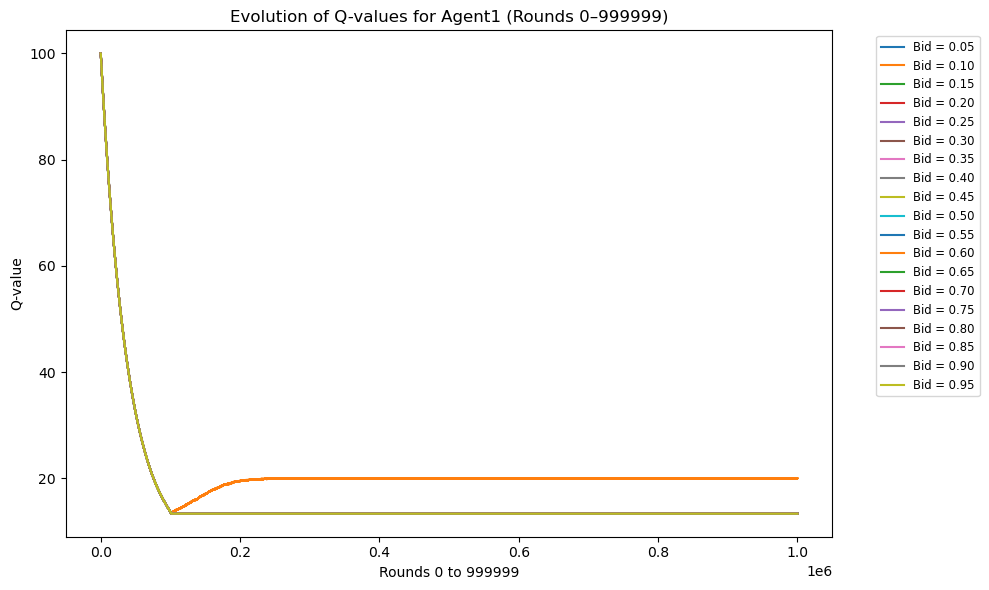

In [15]:
plot_q_evolution_range(history_2, "Agent1", 0, 999999)

In [5]:
import pandas as pd
SPA_convergence = pd.read_csv("SPA_value_0.5.csv")

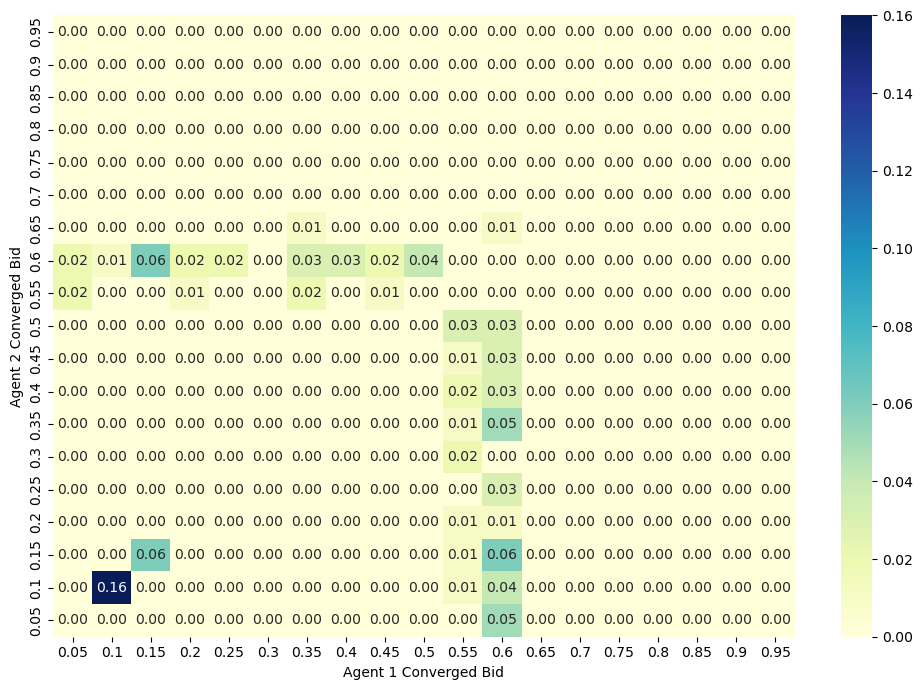

In [8]:
plot_bid_heatmap(SPA_convergence, "SPA_value_0.5")

In [6]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_new = simulation.run()

Agents have not converged after 1,000,000 rounds


In [28]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_new2 = simulation.run()

Convergence detected after 94790 rounds.
Bidder Agent1 converged to bid 0.10.
Bidder Agent2 converged to bid 0.10.


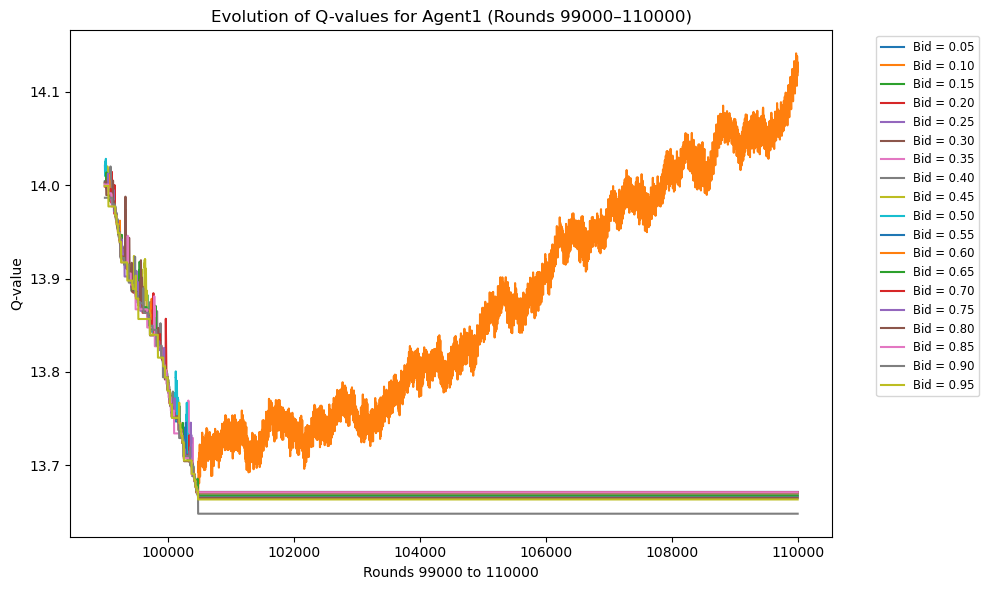

In [35]:
plot_q_evolution_range(history_new, "Agent1", 99000, 110000, title="q_evolution_SPA_0.5_no_convergence", save=True)

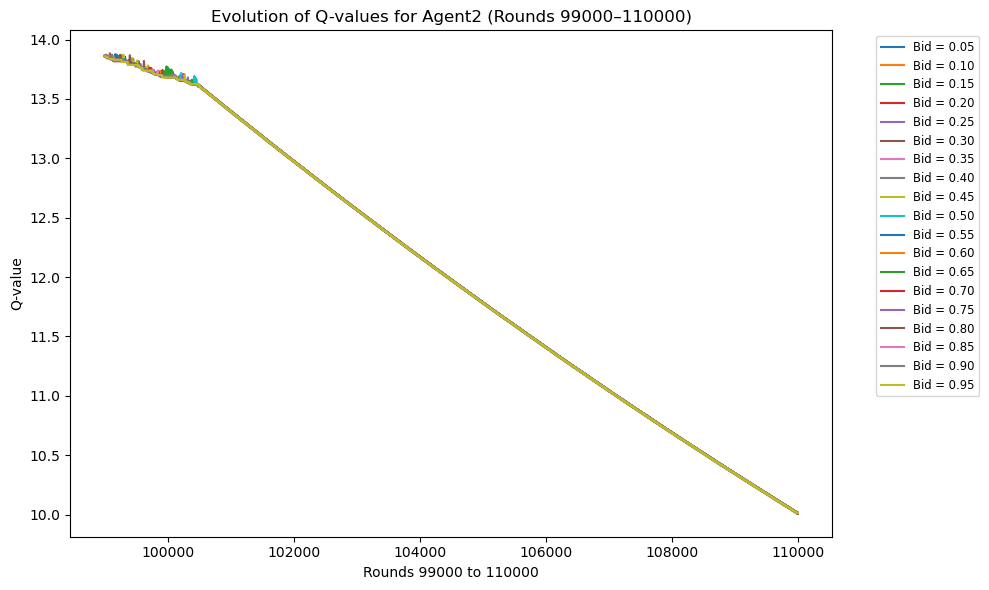

In [16]:
plot_q_evolution_range(history_new, "Agent2", 99000, 110000)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Uses your existing extractor:
# def extract_q_trajectory(history, bidder_name, bid_index): ...

def plot_top_q_counts(history, bidder_name, start=0, end=None,
                      tie="split", seed=None, ax=None):
    """
    Count and plot how many rounds each bid (0.05..0.95, step 0.05) had the highest Q
    for `bidder_name` between rounds [start, end).

    tie: "split" -> split a round equally among all top-tying bids (default)
         "all"   -> give a full count to every top-tying bid
         "random"-> break ties randomly (use `seed` for reproducibility)

    Returns: counts as a numpy array of length 19, aligned with bid_grid.
    """
    bid_grid = np.array([i * 0.05 for i in range(1, 20)])  # 0.05..0.95
    n_bids = len(bid_grid)

    if end is None:
        end = len(history)
    if not (0 <= start < end <= len(history)):
        raise ValueError("Invalid start/end window.")
    if len(history) == 0:
        raise ValueError("Empty history.")

    first_q = history[0][-1][bidder_name]
    if len(first_q) != n_bids:
        raise ValueError(f"Expected {n_bids} actions, found {len(first_q)} in Q-vector.")

    # Q matrix shape: (n_bids, T_window)
    Q = np.vstack([extract_q_trajectory(history, bidder_name, i) for i in range(n_bids)])
    Q = Q[:, start:end]
    T = Q.shape[1]
    if T == 0:
        raise ValueError("Empty window: no rounds to analyze.")

    counts = np.zeros(n_bids, dtype=float)

    if tie == "split":
        col_max = np.max(Q, axis=0)
        is_top = (Q == col_max)
        denom = is_top.sum(axis=0)          # number of top ties per round
        weights = np.where(denom > 0, 1.0 / denom, 0.0)
        counts = (is_top * weights).sum(axis=1)
    elif tie == "all":
        col_max = np.max(Q, axis=0)
        is_top = (Q == col_max)
        counts = is_top.sum(axis=1).astype(float)
    elif tie == "random":
        rng = np.random.default_rng(seed)
        for t in range(T):
            col = Q[:, t]
            top_val = np.max(col)
            top_idx = np.flatnonzero(col == top_val)
            pick = rng.choice(top_idx)
            counts[pick] += 1.0
    else:
        raise ValueError("tie must be one of {'split','all','random'}")

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(n_bids)
    ax.bar(x, counts)
    ax.set_ylabel("Rounds with highest Q")
    ax.set_xlabel("Bid")
    ax.set_xticks(x, [f"{b:.2f}" for b in bid_grid], rotation=45, ha="right")
    ax.set_title(f"Highest-Q rounds for {bidder_name} (t ∈ [{start}, {end}))")
    plt.tight_layout()

    return counts


array([110., 107., 107., 108., 118., 119., 108., 125., 127., 203., 109.,
        88., 148.,  66.,  88.,  63.,  66.,  66.,  74.])

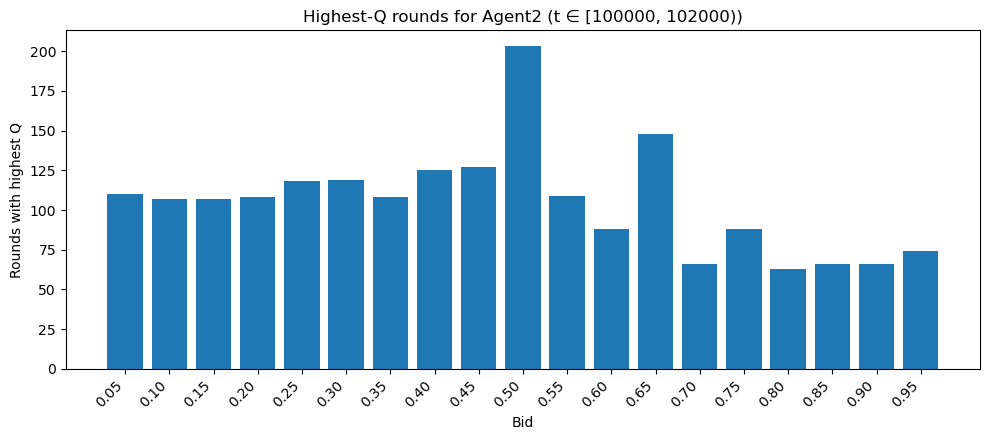

In [32]:
plot_top_q_counts(history_new, "Agent2", 100000, 102000)

History_new2 which is a case where the algorithms learn to converge.

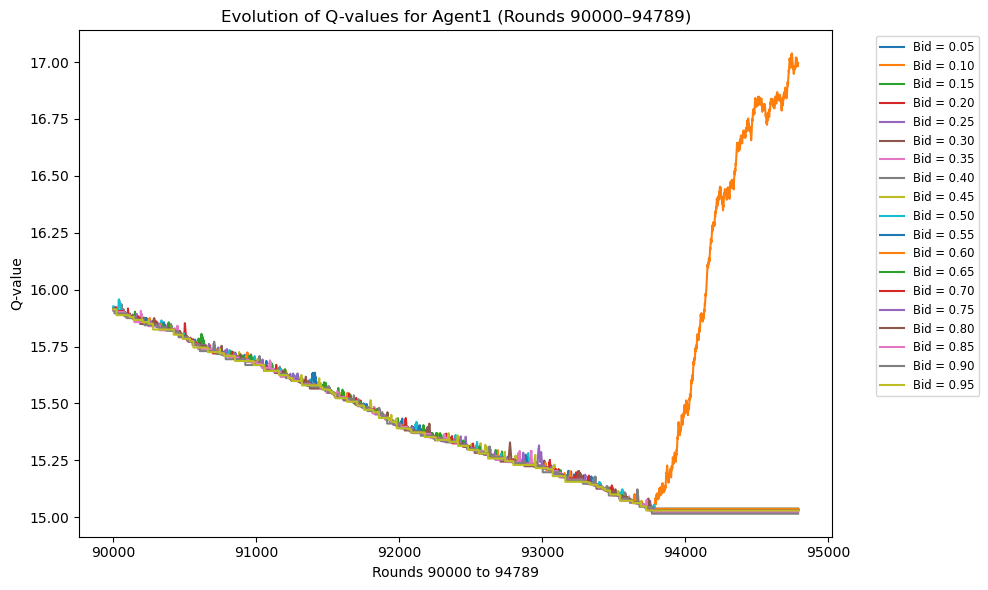

In [31]:
plot_q_evolution_range(history_new2, "Agent1", 90000, 94789)